In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [70]:
def host(doors_arr, player_choice):
    #doors_arr tells the content of the doors
    #the host always chooses a goat door

    ndoors = len(doors_arr)

    for i in range(ndoors):
        if (doors_arr[i] == 0) and (i != player_choice):
            choice = i
            
    return choice

In [65]:
def switcher(available_idxs, firstchoice):
    #always changes choice
    #firstchoice is the index of the door chosen the first time
    
    choice = 0 #index of the new door chosen
    l = len(available_idxs)
    for i in range(l):
        if available_idxs[i] != firstchoice:
            choice = available_idxs[i]
    
    return choice

In [66]:
def newcomer(available_idxs, firstchoice):
    #random choice
    l = len(available_idxs)
    choice = available_idxs[random.randint(0, l-1)]
    return choice #random index 

In [71]:
doors = np.array([0, 0, 1]) #0 = goat, 1 = car
N_iterations = 10000

switcher_wins = 0
conservative_wins = 0
newcomer_wins = 0

j = 0

while j <= N_iterations:
    np.random.shuffle(doors)

    first_choice = random.randint(0, 2) #1st choice of the player (index of the door)
    host_choice = host(doors, first_choice) #index of the door chosen by the host

    available_doors = [] #indices of the doors not yet chosen
    for i in range(len(doors)):
        if i != host_choice:
            available_doors.append(i)

    switcher_choice = switcher(available_doors, first_choice)
    conservative_choice = first_choice
    newcomer_choice = newcomer(available_doors, first_choice)

    if doors[switcher_choice] == 1: #if that index corresponds to the car we record a win
        switcher_wins +=1

    if doors[conservative_choice] == 1:
        conservative_wins +=1

    if doors[newcomer_choice] == 1:
        newcomer_wins +=1

    j += 1


print('Switcher wins: ', switcher_wins, ' (',switcher_wins/N_iterations*100, '%)')
print('Conservative wins: ', conservative_wins, ' (',conservative_wins/N_iterations*100, '%)')
print('Newcomer wins: ', newcomer_wins, ' (',newcomer_wins/N_iterations*100, '%)')

Switcher wins:  6655  ( 66.55 %)
Conservative wins:  3346  ( 33.46 %)
Newcomer wins:  4942  ( 49.419999999999995 %)


In [140]:
# generalising to N total doors and p doors opened by the host; the newcomer function doesn't need upgrades

def new_host(doors_arr, player_choice, p):
    #p = number of doors chosen by the host
    
    ndoors = len(doors_arr)
    possible_choices = [] #indices of the doors that contain goats and are not chosen by the player
    
    for i in range(ndoors):
        if (doors_arr[i] == 0) and (i != player_choice):
            possible_choices.append(i)

    # print(possible_choices)
    
    choices_idxs = np.random.randint(low=0, high=len(possible_choices), size=p) #p random doors are chosen

    choices = []
    for j in range(p):
        choices.append(possible_choices[choices_idxs[j]])
    # print(choices, '\n')
    
    return choices

In [136]:
def new_switcher(available_idxs, firstchoice):
    
    possible_choices = [] #indices of the possible new chosen doors
    l = len(available_idxs)
    
    for i in range(l):
        if available_idxs[i] != firstchoice:
            possible_choices.append(available_idxs[i])
    lp = len(possible_choices)
    choice = possible_choices[random.randint(0, lp-1)]
    
    return choice

In [147]:
def execute_games(N_doors, N_iterations, n_host_doors):
    switcher_wins = 0
    conservative_wins = 0
    newcomer_wins = 0

    j = 0

    while j <= N_iterations:
        doors = np.zeros(N_doors)
        car_idx = random.randint(0, N_doors-1) #we randomly place a car
        doors[car_idx] = 1

        first_choice = random.randint(0, N_doors-1) #1st choice of the player (index of the door)
        host_choices = new_host(doors, first_choice, n_host_doors) #index of the door chosen by the host

        available_doors = [] #indices of the doors not yet chosen
        for i in range(N_doors):
            if i not in host_choices:
                available_doors.append(i)
    
        switcher_choice = new_switcher(available_doors, first_choice)
        conservative_choice = first_choice
        newcomer_choice = newcomer(available_doors, first_choice)

        if doors[switcher_choice] == 1: #if that index corresponds to the car we record a win
            switcher_wins +=1

        if doors[conservative_choice] == 1:
            conservative_wins +=1

        if doors[newcomer_choice] == 1:
            newcomer_wins +=1

        j += 1

    return switcher_wins, conservative_wins, newcomer_wins

In [168]:
# what happens for fixed N_doors and different p?

N_doors = 200
N_iterations = 10000
p_array = np.arange(1, 200, 1)

sw_list = []
cw_list = []
nw_list = []

for i in range(len(p_array)):
    sw, cw, nw = execute_games(N_doors, N_iterations, p_array[i])

    sw_list.append(sw/N_iterations * 100)
    cw_list.append(cw/N_iterations * 100)
    nw_list.append(nw/N_iterations * 100)

Text(0, 0.5, 'Win %')

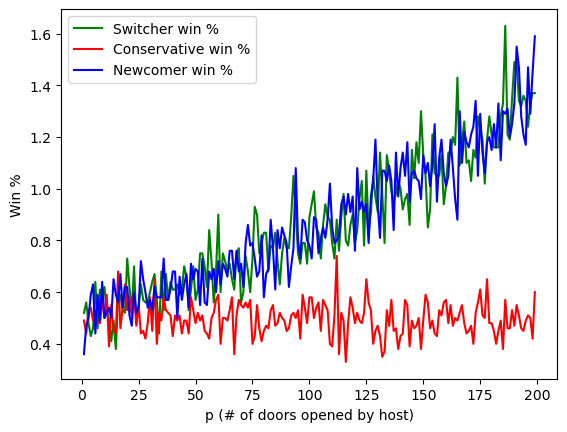

In [169]:
fig, ax = plt.subplots()
plt.plot(p_array, sw_list, color='green', label='Switcher win %')
plt.plot(p_array, cw_list, color='red', label='Conservative win %')
plt.plot(p_array, nw_list, color='blue', label='Newcomer win %')
plt.legend()
ax.set_xlabel('p (# of doors opened by host)')
ax.set_ylabel('Win %')

In [170]:
N_doors_array = np.arange(3, 200)
p = 1

sw_list = []
cw_list = []
nw_list = []

for i in range(len(N_doors_array)):
    sw, cw, nw = execute_games(N_doors_array[i], N_iterations, p)

    sw_list.append(sw/N_iterations * 100)
    cw_list.append(cw/N_iterations * 100)
    nw_list.append(nw/N_iterations * 100)

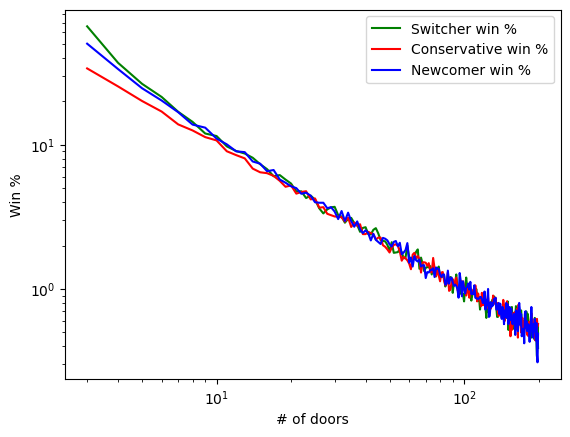

In [176]:
fig, ax = plt.subplots()
plt.plot(N_doors_array, sw_list, color='green', label='Switcher win %')
plt.plot(N_doors_array, cw_list, color='red', label='Conservative win %')
plt.plot(N_doors_array, nw_list, color='blue', label='Newcomer win %')
plt.legend()
ax.set_xlabel('# of doors')
ax.set_ylabel('Win %')
plt.yscale('log')
plt.xscale('log')